# 🔵 Módulo 8: Técnicas de Clustering

## Objetivos de Aprendizagem

Ao final deste módulo, você será capaz de:

1. **Aplicar o algoritmo K-means** — compreender a função objetivo de inércia, o processo iterativo de atribuição/atualização e os critérios de convergência
2. **Determinar o número ideal de clusters** — usar o Método do Cotovelo (Elbow) e o Coeficiente de Silhueta
3. **Interpretar e visualizar clusters** — analisar perfis de segmentos e criar visualizações multidimensionais
4. **Usar Clustering Hierárquico** — construir e interpretar dendrogramas com diferentes métodos de linkage
5. **Aplicar DBSCAN** — detectar clusters de formas arbitrárias e identificar pontos de ruído/outliers

## Teoria: Algoritmos de Clustering

### K-means — Função Objetivo (Inércia)

O K-means minimiza a soma das distâncias quadráticas de cada ponto ao centróide do seu cluster:

$$J = \sum_{k=1}^K \sum_{x \in C_k} ||x - \mu_k||^2$$

**Atualização do centróide:**

$$\mu_k = \frac{1}{|C_k|} \sum_{x \in C_k} x$$

**Algoritmo (Lloyd):**
1. Inicializar K centróides (aleatório ou K-means++)
2. **Atribuição:** cada ponto vai para o centróide mais próximo
3. **Atualização:** recalcular centróides como média do cluster
4. Repetir até convergência (centróides não mudam)

---

### Coeficiente de Silhueta

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Onde:
- $a(i)$ = distância média do ponto $i$ aos demais pontos do **mesmo cluster** (coesão interna)
- $b(i)$ = distância média do ponto $i$ ao cluster **vizinho mais próximo** (separação externa)
- $s(i) \in [-1, 1]$ — próximo de **+1** = bem agrupado | próximo de **0** = na fronteira | próximo de **-1** = no cluster errado

---

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Parâmetros: **ε** (raio de vizinhança), **MinPts** (mínimo de pontos)

**Vizinhança de um ponto p:**
$$N_\varepsilon(p) = \{q \in D \mid dist(p,q) \leq \varepsilon\}$$

**Tipos de pontos:**
- **Ponto Core (Núcleo):** $|N_\varepsilon(p)| \geq \text{MinPts}$ — tem vizinhança densa suficiente
- **Ponto Border (Borda):** na vizinhança de um core, mas não é core
- **Ponto Noise (Ruído):** nem core nem border — é um outlier

---

### Clustering Hierárquico

Constrói uma hierarquia de clusters, visualizada como **dendrograma**.

**Métodos de Linkage:**
| Método | Distância entre clusters | Característica |
|---|---|---|
| **Single** | Mínima entre pontos | Tende a encadear clusters (chaining) |
| **Complete** | Máxima entre pontos | Clusters compactos e esféricos |
| **Average** | Média de todas as distâncias | Equilíbrio entre single e complete |
| **Ward** | Minimiza variância intra-cluster | Recomendado para dados contínuos |

> **Ward** minimiza a variância total intra-cluster após cada fusão — geralmente produz os clusters mais equilibrados.

Dataset: Segmentação de Clientes (RFM)
Total de clientes: 500


,Recencia_dias,Frequencia_compras,Valor_medio_R$
count,500.00,500.00,500.00
mean,41.31,6.33,268.03
std,31.48,5.22,209.07
min,0.43,0.00,2.05
25%,14.14,2.03,90.26
50%,33.75,4.98,216.27
75%,58.81,9.42,420.66
max,109.23,20.20,776.84


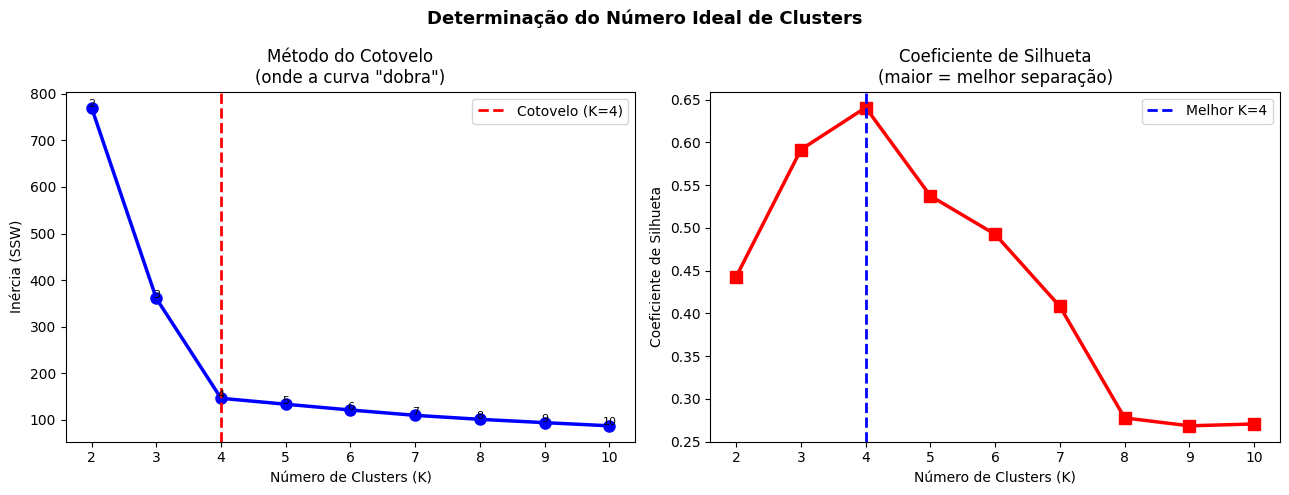

Melhor K pelo critério de silhueta: K = 4


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Dataset: Segmentação de clientes (RFM)
# R = Recencia, F = Frequencia, M = Valor Monetario
n = 500
centers_rfm = [[10, 1, 50], [45, 8, 350], [90, 3, 120], [20, 15, 600]]
labels_reais = []
X_rfm = []
for i, (center, n_pts) in enumerate(zip(centers_rfm, [150, 130, 120, 100])):
    pts = np.random.randn(n_pts, 3) * [8, 2, 80] + center
    X_rfm.append(pts)
    labels_reais.extend([i] * n_pts)
X_rfm = np.vstack(X_rfm)
X_rfm = np.abs(X_rfm)

df_clientes = pd.DataFrame(X_rfm, columns=['Recencia_dias', 'Frequencia_compras', 'Valor_medio_R$'])
print("Dataset: Segmentação de Clientes (RFM)")
print(f"Total de clientes: {len(df_clientes)}")
display(df_clientes.describe().round(2))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clientes)

# Elbow Method + Silhueta
inercias = []
silhuetas = []
Ks = range(2, 11)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Determinação do Número Ideal de Clusters', fontsize=13, fontweight='bold')

axes[0].plot(Ks, inercias, 'bo-', lw=2.5, ms=8)
axes[0].axvline(4, color='red', lw=2, linestyle='--', label='Cotovelo (K=4)')
axes[0].set_xlabel('Número de Clusters (K)'); axes[0].set_ylabel('Inércia (SSW)')
axes[0].set_title('Método do Cotovelo\n(onde a curva "dobra")')
axes[0].legend()
for k, v in zip(Ks, inercias):
    axes[0].text(k, v+1, str(k), ha='center', fontsize=8)

axes[1].plot(Ks, silhuetas, 'rs-', lw=2.5, ms=8)
best_k = Ks[np.argmax(silhuetas)]
axes[1].axvline(best_k, color='blue', lw=2, linestyle='--', label=f'Melhor K={best_k}')
axes[1].set_xlabel('Número de Clusters (K)'); axes[1].set_ylabel('Coeficiente de Silhueta')
axes[1].set_title('Coeficiente de Silhueta\n(maior = melhor separação)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../imagens/08_elbow_silhueta.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Melhor K pelo critério de silhueta: K = {best_k}")

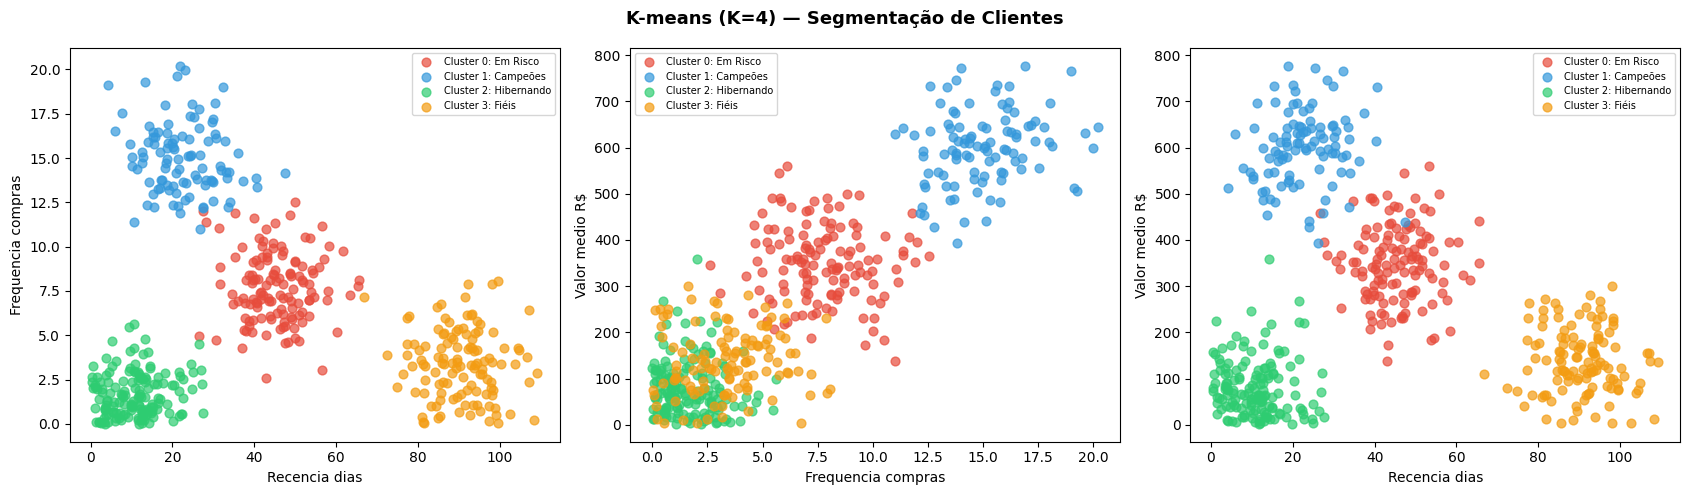


Perfil dos Clusters:


,Recencia_dias,Frequencia_compras,Valor_medio_R$,N
Cluster 0: Em Risco,45.4,7.7,348.9,130
Cluster 1: Campeões,22.6,15.0,599.8,100
Cluster 2: Hibernando,10.9,1.7,80.4,150
Cluster 3: Fiéis,90.5,3.4,138.4,120



Coeficiente de Silhueta médio (K=4): 0.641


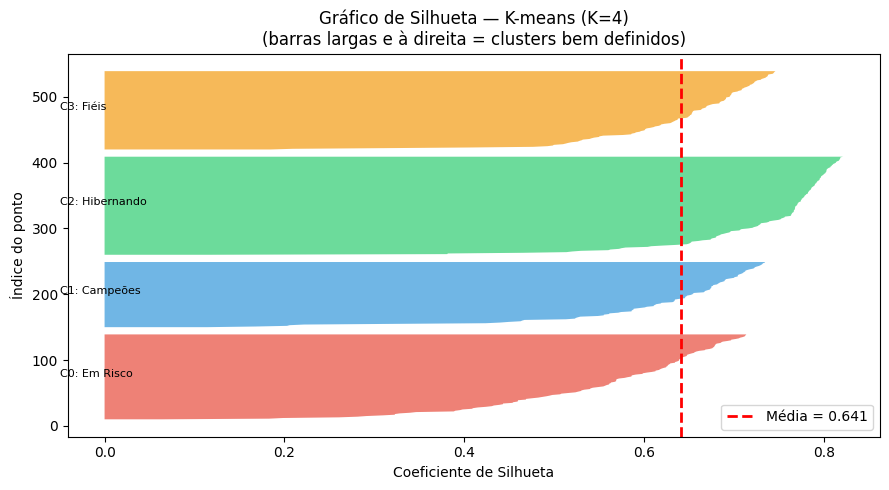

In [2]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km_final.fit_predict(X_scaled)
df_clientes['Cluster'] = labels

cores_cluster = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
nomes_segmentos = ['Em Risco', 'Campeões', 'Hibernando', 'Fiéis']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('K-means (K=4) — Segmentação de Clientes', fontsize=13, fontweight='bold')

for ax, (x_feat, y_feat) in zip(axes, [
    ('Recencia_dias', 'Frequencia_compras'),
    ('Frequencia_compras', 'Valor_medio_R$'),
    ('Recencia_dias', 'Valor_medio_R$'),
]):
    for k, (cor, nome) in enumerate(zip(cores_cluster, nomes_segmentos)):
        mask = labels == k
        ax.scatter(df_clientes[mask][x_feat], df_clientes[mask][y_feat],
                    c=cor, s=40, alpha=0.7, label=f'Cluster {k}: {nome}')
    ax.set_xlabel(x_feat.replace('_', ' ')); ax.set_ylabel(y_feat.replace('_', ' '))
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../imagens/08_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Perfil dos clusters
perfil = df_clientes.groupby('Cluster').agg({'Recencia_dias': 'mean', 
                                               'Frequencia_compras': 'mean', 
                                               'Valor_medio_R$': 'mean',
                                               'Cluster': 'count'}).rename(columns={'Cluster': 'N'})
perfil.index = [f'Cluster {i}: {nomes_segmentos[i]}' for i in range(4)]
print("\nPerfil dos Clusters:")
display(perfil.round(1))

# Gráfico de silhueta por cluster
sil_vals = silhouette_samples(X_scaled, labels)
sil_medio = silhouette_score(X_scaled, labels)
print(f"\nCoeficiente de Silhueta médio (K=4): {sil_medio:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for k, cor in enumerate(cores_cluster):
    sil_k = np.sort(sil_vals[labels == k])
    size_k = len(sil_k)
    y_upper = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k, facecolor=cor, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5*size_k, f'C{k}: {nomes_segmentos[k]}', fontsize=8)
    y_lower = y_upper + 10

ax.axvline(sil_medio, color='red', lw=2, linestyle='--', label=f'Média = {sil_medio:.3f}')
ax.set_xlabel('Coeficiente de Silhueta'); ax.set_ylabel('Índice do ponto')
ax.set_title('Gráfico de Silhueta — K-means (K=4)\n(barras largas e à direita = clusters bem definidos)')
ax.legend()
plt.tight_layout()
plt.savefig('../imagens/08_silhueta_grafico.png', dpi=150, bbox_inches='tight')
plt.show()

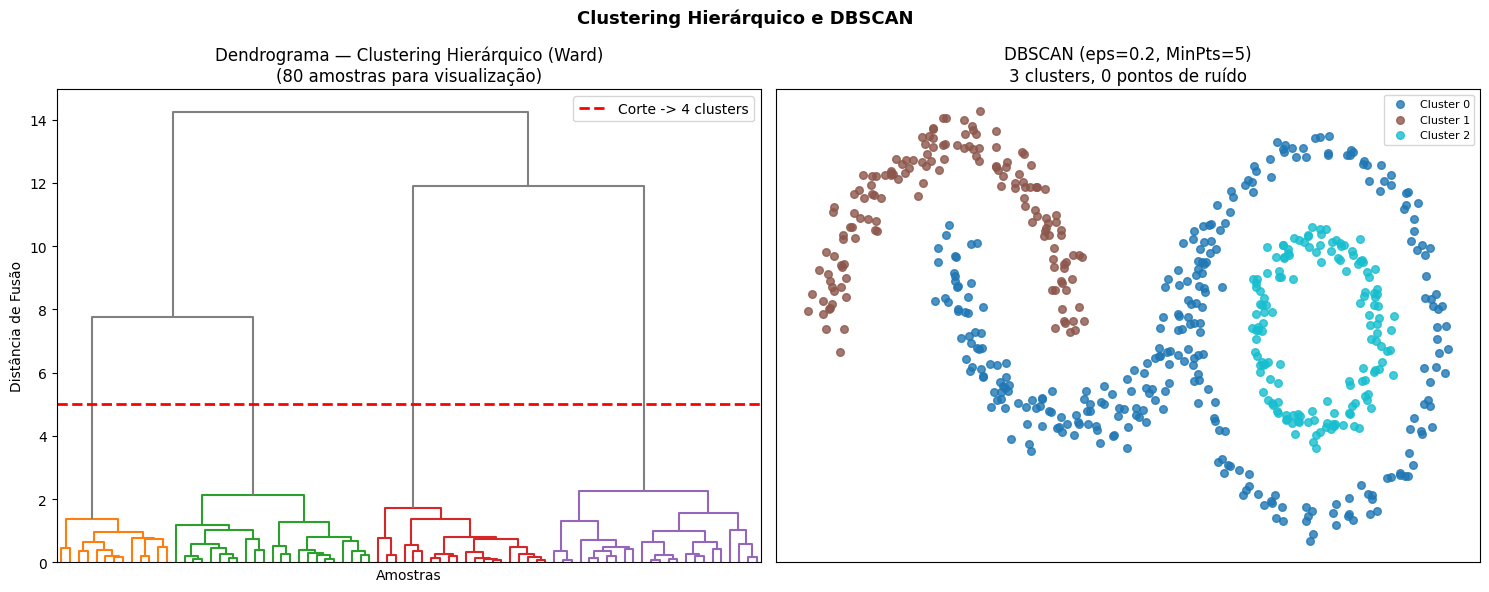


Comparação no dataset de formas irregulares:


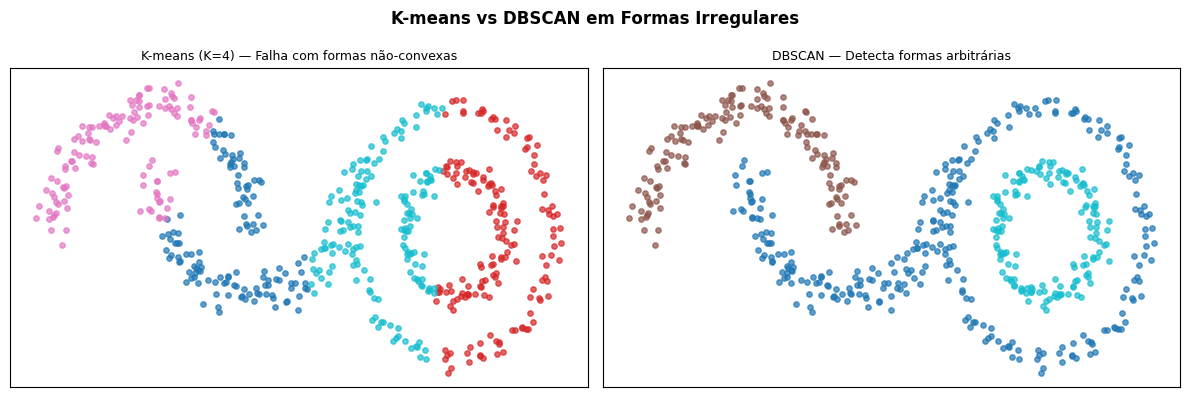

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Clustering Hierárquico e DBSCAN', fontsize=13, fontweight='bold')

# Dendrograma
amostra_idx = np.random.choice(len(X_scaled), 80, replace=False)
Z = linkage(X_scaled[amostra_idx], method='ward')
dendrogram(Z, ax=axes[0], no_labels=True, color_threshold=5,
            above_threshold_color='gray', leaf_font_size=7)
axes[0].axhline(5, color='red', lw=2, linestyle='--', label='Corte -> 4 clusters')
axes[0].set_title('Dendrograma — Clustering Hierárquico (Ward)\n(80 amostras para visualização)')
axes[0].set_xlabel('Amostras'); axes[0].set_ylabel('Distância de Fusão')
axes[0].legend()

# DBSCAN em dataset 2D com formas irregulares
from sklearn.datasets import make_moons, make_circles
X_moon, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
X_dbscan = np.vstack([X_moon, X_circles + [3, 0]])

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_db = dbscan.fit_predict(X_dbscan)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido = (labels_db == -1).sum()

cores_db = plt.cm.tab10(np.linspace(0, 1, max(n_clusters_db, 1)))
for label in sorted(set(labels_db)):
    mask = labels_db == label
    cor = 'black' if label == -1 else cores_db[label % n_clusters_db]
    marcador = 'x' if label == -1 else 'o'
    rotulo = f'Ruído ({n_ruido})' if label == -1 else f'Cluster {label}'
    axes[1].scatter(X_dbscan[mask, 0], X_dbscan[mask, 1], c=[cor], 
                     marker=marcador, s=30, alpha=0.8, label=rotulo)
axes[1].set_title(f'DBSCAN (eps=0.2, MinPts=5)\n{n_clusters_db} clusters, {n_ruido} pontos de ruído')
axes[1].legend(fontsize=8)
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.savefig('../imagens/08_hierarquico_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparação K-means vs DBSCAN no mesmo dataset
print("\nComparação no dataset de formas irregulares:")
km_db = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km_db = km_db.fit_predict(X_dbscan)

fig, axes2 = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('K-means vs DBSCAN em Formas Irregulares', fontsize=12, fontweight='bold')

for ax, (lbs, titulo) in zip(axes2, [
    (labels_km_db, 'K-means (K=4) — Falha com formas não-convexas'),
    (labels_db, f'DBSCAN — Detecta formas arbitrárias'),
]):
    unique_labels = sorted(set(lbs))
    cmap = plt.cm.tab10
    for lbl in unique_labels:
        mask = lbs == lbl
        cor = 'black' if lbl == -1 else cmap(lbl / max(len(unique_labels)-1, 1))
        ax.scatter(X_dbscan[mask, 0], X_dbscan[mask, 1], c=[cor], s=15, alpha=0.7)
    ax.set_title(titulo, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('../imagens/08_comparacao_kmeans_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

## Tabela Comparativa dos Algoritmos de Clustering

| Característica | K-means | Hierárquico | DBSCAN |
|---|---|---|---|
| **Número de clusters** | Definido pelo usuário (K) | Determinado pelo corte no dendrograma | Determinado automaticamente |
| **Formato dos clusters** | Esférico/convexo | Variável (depende do linkage) | Arbitrário (qualquer forma) |
| **Ruído/Outliers** | Atribuídos ao cluster mais próximo | Atribuídos ao cluster mais próximo | Identificados explicitamente |
| **Escalabilidade** | Alta (O(n·K·t)) | Baixa (O(n²) a O(n³)) | Média (O(n log n) com índice) |
| **Interpretabilidade** | Alta (centróides intuitivos) | Alta (dendrograma visual) | Média (parâmetros ε e MinPts) |
| **Sensibilidade** | Inicialização aleatória | Ordem dos dados (single linkage) | ε e MinPts |
| **Dados categóricos** | Não (usar K-modes) | Sim (com distância adequada) | Sim (com distância adequada) |

---

### Quando Usar Cada Algoritmo?

**Use K-means quando:**
- O dataset é grande (> 10.000 pontos) e precisa de eficiência computacional
- Os clusters esperados têm forma aproximadamente esférica
- Você tem uma estimativa razoável do número de clusters
- Exemplos: segmentação de clientes, compressão de imagens, quantização de vetores

**Use Clustering Hierárquico quando:**
- Você não sabe o número de clusters e quer explorar diferentes granularidades
- Precisa de uma hierarquia interpretável (taxonomias, filogenia)
- O dataset é pequeno/médio (até ~5.000 pontos)
- Exemplos: análise genômica, agrupamento de documentos, segmentação de mercados

**Use DBSCAN quando:**
- Os clusters têm formas irregulares ou não-convexas
- Há ruído/outliers que precisam ser identificados
- Você não sabe o número de clusters de antemão
- Exemplos: análise geoespacial, detecção de anomalias, imagens de satélite

---

### Dicas Práticas

1. **Sempre normalize os dados** antes de aplicar qualquer algoritmo baseado em distância (K-means, DBSCAN, Hierárquico com Euclidiana)
2. **K-means++** (padrão no sklearn) melhora significativamente a inicialização dos centróides
3. **Para DBSCAN**, use o gráfico de k-distância para estimar ε: ordene os pontos pela distância ao k-ésimo vizinho e procure o "joelho" da curva
4. **Valide os clusters** usando silhueta, Davies-Bouldin Index e, quando possível, validação de domínio com especialistas

---

### Exercícios Propostos

**Exercício 1 — Sensibilidade a K**
Execute K-means com K de 2 a 8 no dataset RFM. Plote os clusters em scatter 2D para cada K. A partir de qual K os clusters deixam de ser intuitivamente interpretáveis?

**Exercício 2 — Análise de Silhueta Detalhada**
Crie o gráfico de silhueta individual (silhouette_samples) para K=3, K=4 e K=5. Compare visualmente — qual K tem clusters mais coesos?

**Exercício 3 — Sensibilidade do DBSCAN**
No dataset de formas irregulares, experimente ε de 0.1 a 0.5 e MinPts de 3 a 10. Como esses parâmetros afetam o número de clusters e a quantidade de ruído? Construa uma grade (grid search) de eps × min_samples.

**Exercício 4 — Comparação de Linkages**
Aplique Clustering Hierárquico com os métodos single, complete, average e ward no dataset RFM. Compare os dendrogramas. Qual método produz clusters mais balanceados?

**Exercício 5 — Aplicação em Negócio**
Com os 4 segmentos identificados pelo K-means (Em Risco, Campeões, Hibernando, Fiéis), proponha estratégias de marketing personalizadas para cada segmento. Quais ações você recomendaria para reativar os clientes "Hibernando"? Como fidelizar ainda mais os "Campeões"?